=== 可直接复制的甩龙排列结果（数组格式）===
（直接复制下方内容到你的数组中即可）
------------------------------------------------------------
    296.1700945, 296.2075737, 296.2536147, 296.3039785, 296.3530762, 296.3978519,
    296.4401734, 296.4868056, 296.5502050, 296.6589626, 296.8024740, 296.9904208,
    297.1237213, 296.8821284, 296.7250415, 296.6030330, 296.5185053, 296.4621699,
    296.4185897, 296.3771140, 296.3287823, 296.2787188, 296.2301133, 296.1875010
------------------------------------------------------------

=== 序号对照（验证排列规律）===
序号	数值
------------------------------
 1	296.1700945
 2	296.2075737
 3	296.2536147
 4	296.3039785
 5	296.3530762
 6	296.3978519
 7	296.4401734
 8	296.4868056
 9	296.5502050
10	296.6589626
11	296.8024740
12	296.9904208
13	297.1237213
14	296.8821284
15	296.7250415
16	296.6030330
17	296.5185053
18	296.4621699
19	296.4185897
20	296.3771140
21	296.3287823
22	296.2787188
23	296.2301133
24	296.1875010


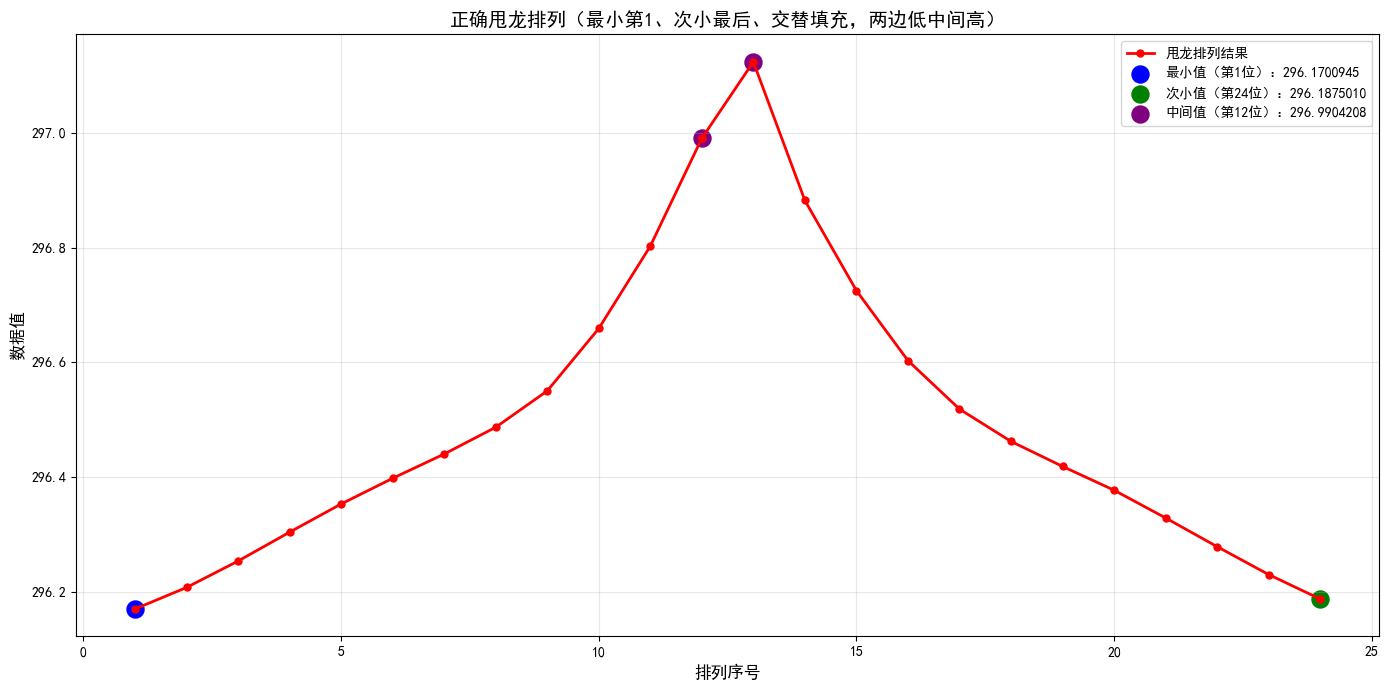

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 原始数据（24个数值）
raw_data = np.array([
    297.1237213, 296.9904208, 296.8821284, 296.802474, 296.7250415, 296.6589626,
    296.603033, 296.550205, 296.5185053, 296.4868056, 296.4621699, 296.4401734,
    296.4185897, 296.3978519, 296.377114, 296.3530762, 296.3287823, 296.3039785,
    296.2787188, 296.2536147, 296.2301133, 296.2075737, 296.187501, 296.1700945
])

# 2. 核心：正确的甩龙排列（最小第1，次小最后，第三小第2，第四小倒数第2...）
def correct_dragon_arrange(data):
    # 步骤1：升序排序（得到 最小→次小→...→次大→最大 的序列）
    sorted_asc = np.sort(data)
    n = len(sorted_asc)
    dragon_result = np.zeros_like(sorted_asc)  # 初始化结果数组
    
    # 步骤2：双指针交替填充（左指针从头部开始，右指针从尾部开始）
    left_ptr = 0  # 左指针：指向结果数组头部
    right_ptr = n - 1  # 右指针：指向结果数组尾部
    
    for i in range(n):
        if i % 2 == 0:
            # 偶数索引（0,2,4...）：填入左指针位置，左指针右移
            dragon_result[left_ptr] = sorted_asc[i]
            left_ptr += 1
        else:
            # 奇数索引（1,3,5...）：填入右指针位置，右指针左移
            dragon_result[right_ptr] = sorted_asc[i]
            right_ptr -= 1
    
    return dragon_result

# 3. 执行排列
dragon_result = correct_dragon_arrange(raw_data)

# 4. 格式化输出：可直接复制到数组的格式（和示例格式一致）
print("=== 可直接复制的甩龙排列结果（数组格式）===")
print("（直接复制下方内容到你的数组中即可）")
print("-" * 60)
# 配置每行显示6个数值（和你的示例对齐，更整洁）
items_per_line = 6
for idx in range(0, len(dragon_result), items_per_line):
    # 截取当前行的数值
    line_data = dragon_result[idx:idx+items_per_line]
    # 转换为字符串，用", "分隔
    line_str = ", ".join([f"{val:.7f}" for val in line_data])
    # 每行末尾添加逗号（最后一行可选，保持和示例格式一致）
    if idx + items_per_line < len(dragon_result):
        line_str += ","
    # 缩进对齐（和你的示例一致，用4个空格）
    print(f"    {line_str}")
print("-" * 60)

# 5. 可选：打印序号对照（验证排列规律）
print("\n=== 序号对照（验证排列规律）===")
print("序号\t数值")
print("-" * 30)
for idx, val in enumerate(dragon_result, 1):
    print(f"{idx:2d}\t{val:.7f}")

# 6. 保留可视化验证功能
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 7))
# 绘制排列结果曲线
plt.plot(range(1, 25), dragon_result, 'r-', linewidth=2, marker='o', markersize=5, label='甩龙排列结果')
# 标注关键节点
plt.scatter(1, dragon_result[0], color='blue', s=150, label=f'最小值（第1位）：{dragon_result[0]:.7f}')
plt.scatter(24, dragon_result[-1], color='green', s=150, label=f'次小值（第24位）：{dragon_result[-1]:.7f}')
plt.scatter(12, dragon_result[11], color='purple', s=150, label=f'中间值（第12位）：{dragon_result[11]:.7f}')
plt.scatter(13, dragon_result[12], color='purple', s=150)

# 图表配置
plt.xlabel('排列序号', fontsize=12)
plt.ylabel('数据值', fontsize=12)
plt.title('正确甩龙排列（最小第1、次小最后、交替填充，两边低中间高）', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

=== 最终结果：任意<24数据→甩龙排列→优先补最大差距→24个数据 ===
（直接复制下方内容到你的数组中即可）
----------------------------------------------------------------------
    281.5728003, 281.8359232, 282.0780656, 282.3339450, 282.5737068, 282.9047068,
    283.2342312, 283.5637557, 283.9398778, 284.3159999, 284.5201873, 284.7243747,
    284.5252518, 284.3261289, 284.1270060, 283.9278831, 283.5753015, 283.2227200,
    282.9158430, 282.6089660, 282.3340580, 282.1234195, 281.9290924, 281.7467061
----------------------------------------------------------------------

=== 插值补充说明 ===
输入数据长度：16 → 补充 8 个点（优先补相邻差距最大的位置）
甩龙排列后，初始最大差距位置：第 9 个与第 10 个数据之间（差距：0.7964916）


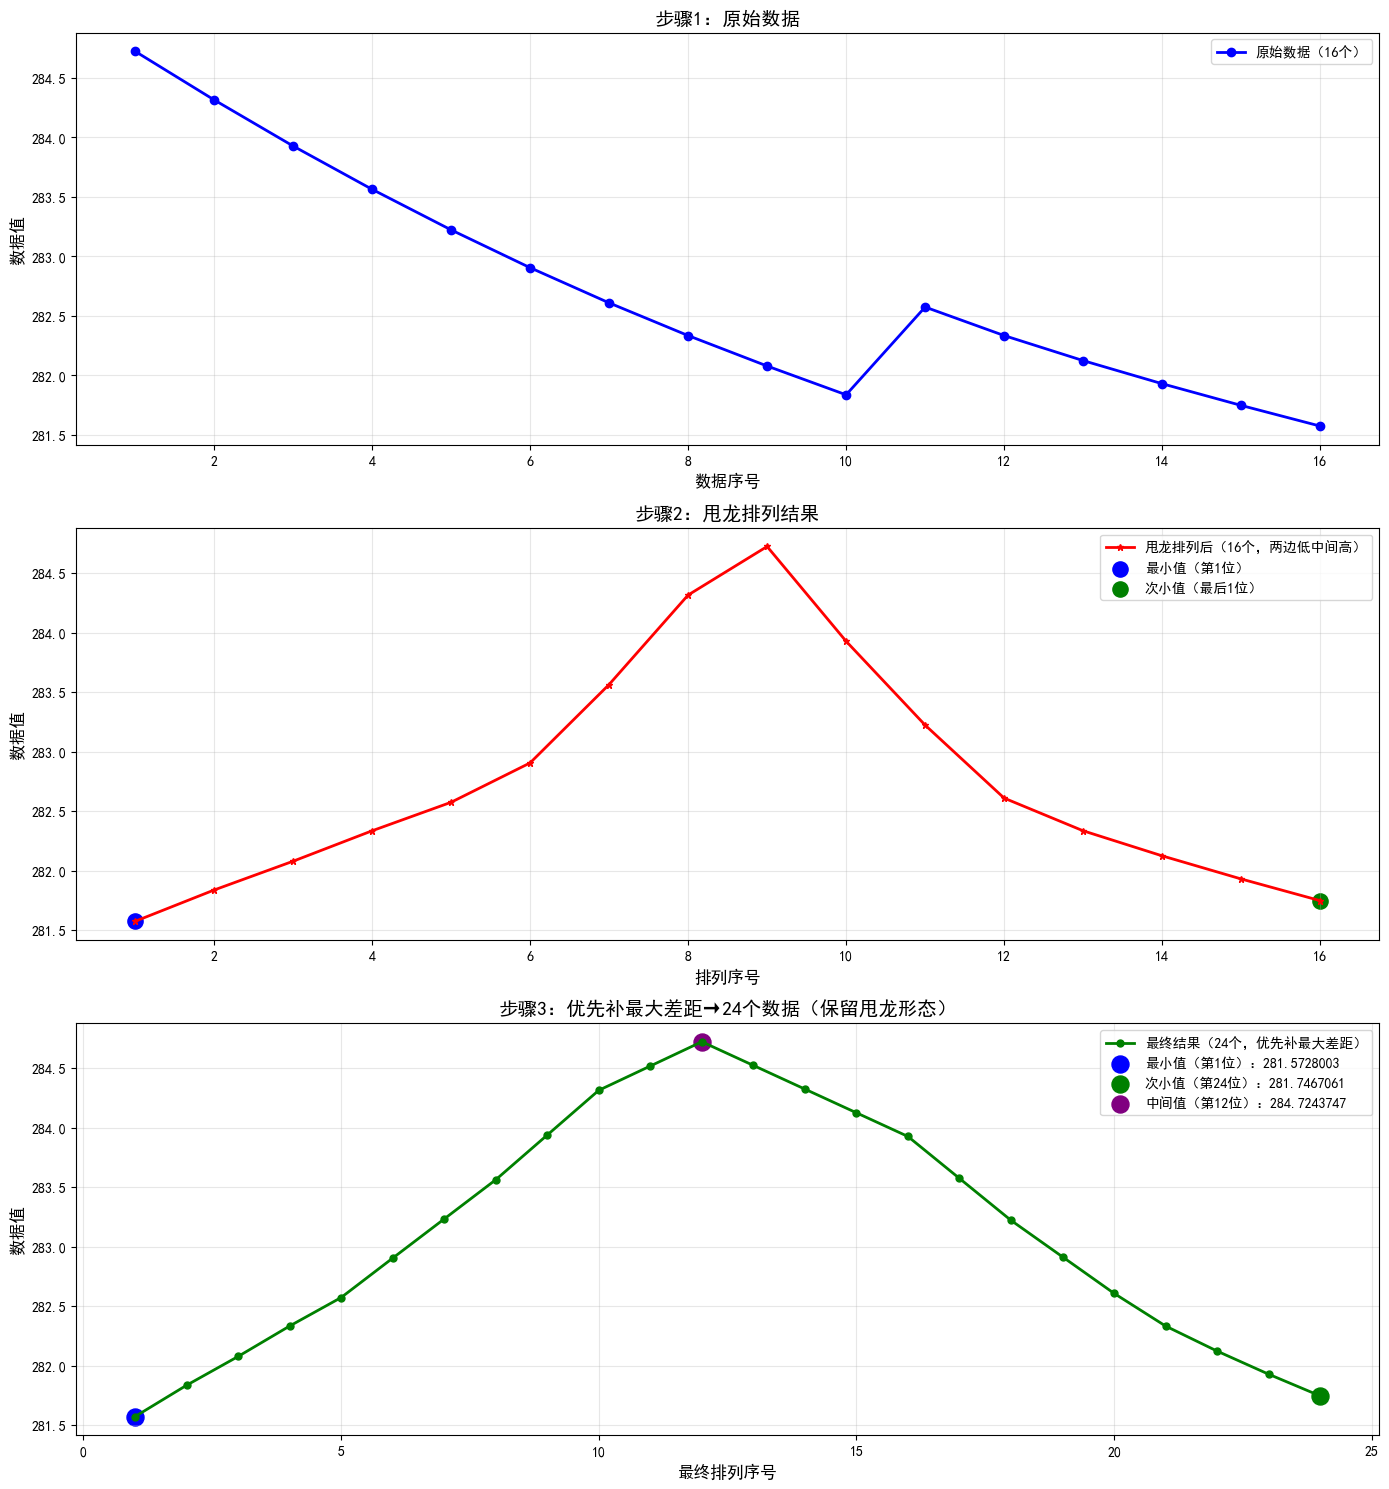

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 通用工具函数：找相邻数据差距最大的位置（返回排序后的差距索引）
def find_largest_gap_indices(data):
    # 计算相邻数据的差值绝对值
    gaps = np.abs(np.diff(data))
    # 得到差距的索引（0对应data[0]和data[1]之间，以此类推）
    gap_indices = np.arange(len(gaps))
    # 按差距从大到小排序，返回索引
    sorted_gap_indices = gap_indices[np.argsort(gaps)[::-1]]
    return sorted_gap_indices, gaps

# 2. 通用工具函数：在指定位置插值补充数据（优先补差距大的位置，线性插值）
def interpolate_at_largest_gaps(data, target_len=24):
    n_original = len(data)
    if n_original >= target_len:
        return data[:target_len]
    
    add_num = target_len - n_original  # 需要补充的点数
    data_copy = np.array(data, dtype=np.float64)  # 避免修改原始数据
    
    for _ in range(add_num):
        # 每次都重新计算差距（因为数据在更新）
        sorted_gap_indices, gaps = find_largest_gap_indices(data_copy)
        # 选择当前差距最大的位置
        largest_gap_idx = sorted_gap_indices[0]
        
        # 线性插值：在data_copy[largest_gap_idx]和data_copy[largest_gap_idx+1]之间插入中间值
        val_left = data_copy[largest_gap_idx]
        val_right = data_copy[largest_gap_idx + 1]
        insert_val = (val_left + val_right) / 2.0
        
        # 插入插值结果
        data_copy = np.insert(data_copy, largest_gap_idx + 1, insert_val)
    
    return data_copy

# 3. 通用甩龙排列函数（适配任意长度数据）
def correct_dragon_arrange(data):
    sorted_asc = np.sort(data)
    n = len(sorted_asc)
    dragon_result = np.zeros_like(sorted_asc)
    
    left_ptr = 0
    right_ptr = n - 1
    
    for i in range(n):
        if i % 2 == 0:
            dragon_result[left_ptr] = sorted_asc[i]
            left_ptr += 1
        else:
            dragon_result[right_ptr] = sorted_asc[i]
            right_ptr -= 1
    
    return dragon_result

# 4. 通用主流程函数（输入任意<24的数据，返回最终24个数据）
def process_any_data_to_24(raw_data):
    # 步骤1：甩龙排列
    dragon_data = correct_dragon_arrange(raw_data)
    # 步骤2：优先补差距最大的位置，插值扩充至24个
    final_24_data = interpolate_at_largest_gaps(dragon_data, target_len=24)
    return dragon_data, final_24_data

# 5. 测试数据（本次21个数据，可替换为任意<24的数据）
raw_data = np.array([
    284.7243747	,284.3159999	,283.9278831	,283.5637557	,283.22272	,282.9047068	,282.608966	,282.333945	,282.0780656	,281.8359232	,282.5737068	,282.334058	,282.1234195	,281.9290924	,281.7467061	,281.5728003





])

# 6. 执行通用流程
dragon_data, final_24_data = process_any_data_to_24(raw_data)

# 7. 格式化输出（可直接复制的数组格式）
print("=== 最终结果：任意<24数据→甩龙排列→优先补最大差距→24个数据 ===")
print("（直接复制下方内容到你的数组中即可）")
print("-" * 70)
items_per_line = 6
for idx in range(0, len(final_24_data), items_per_line):
    line_data = final_24_data[idx:idx+items_per_line]
    line_str = ", ".join([f"{val:.7f}" for val in line_data])
    if idx + items_per_line < len(final_24_data):
        line_str += ","
    print(f"    {line_str}")
print("-" * 70)

# 8. 可选：打印补充过程说明（验证差距最大的位置）
print("\n=== 插值补充说明 ===")
print(f"输入数据长度：{len(raw_data)} → 补充 {24 - len(raw_data)} 个点（优先补相邻差距最大的位置）")
initial_gaps = np.abs(np.diff(dragon_data))
max_initial_gap_idx = np.argmax(initial_gaps)
print(f"甩龙排列后，初始最大差距位置：第 {max_initial_gap_idx+1} 个与第 {max_initial_gap_idx+2} 个数据之间（差距：{initial_gaps[max_initial_gap_idx]:.7f}）")

# 9. 可视化（通用化，适配任意输入数据）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15))

# 子图1：原始数据
ax1.plot(range(1, len(raw_data)+1), raw_data, 'bo-', linewidth=2, markersize=6, label=f'原始数据（{len(raw_data)}个）')
ax1.set_xlabel('数据序号', fontsize=12)
ax1.set_ylabel('数据值', fontsize=12)
ax1.set_title('步骤1：原始数据', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# 子图2：甩龙排列后数据
ax2.plot(range(1, len(dragon_data)+1), dragon_data, 'r*-', linewidth=2, markersize=5, label=f'甩龙排列后（{len(dragon_data)}个，两边低中间高）')
ax2.scatter(1, dragon_data[0], color='blue', s=120, label='最小值（第1位）')
ax2.scatter(len(dragon_data), dragon_data[-1], color='green', s=120, label='次小值（最后1位）')
ax2.set_xlabel('排列序号', fontsize=12)
ax2.set_ylabel('数据值', fontsize=12)
ax2.set_title('步骤2：甩龙排列结果', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

# 子图3：最终24个数据（优先补最大差距）
ax3.plot(range(1, 25), final_24_data, 'g-', linewidth=2, marker='o', markersize=5, label='最终结果（24个，优先补最大差距）')
ax3.scatter(1, final_24_data[0], color='blue', s=150, label=f'最小值（第1位）：{final_24_data[0]:.7f}')
ax3.scatter(24, final_24_data[-1], color='green', s=150, label=f'次小值（第24位）：{final_24_data[-1]:.7f}')
ax3.scatter(12, final_24_data[11], color='purple', s=150, label=f'中间值（第12位）：{final_24_data[11]:.7f}')
ax3.set_xlabel('最终排列序号', fontsize=12)
ax3.set_ylabel('数据值', fontsize=12)
ax3.set_title('步骤3：优先补最大差距→24个数据（保留甩龙形态）', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best')

plt.tight_layout()
plt.show()